# E-ML - Phishing Email Detection with Machine Learning Methods
### By Colin Harrison, Aidan Huerta, and Drew Levy
---

In [18]:
print("Importing necessary libraries...\n")
!pip install gensim
import datasets
import re
import requests
import nltk
import sklearn
import torch
import random

import warnings
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nltk import word_tokenize, FreqDist, pos_tag

from sklearn import linear_model, metrics

from sklearn.feature_extraction.text import *

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, f1_score, recall_score

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import uniform, randint
from sklearn.linear_model import LogisticRegression

from huggingface_hub import hf_hub_download
import joblib

from transformers import AutoTokenizer, AutoModel


from typing import Any, Dict, Iterable, List, Optional, Set, Tuple

import gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

from xgboost import XGBClassifier

# Might be necessary
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('universal_tagset', quiet=True)

# Set the Seeds
SEED = 42
random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set the Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected; training may be slow")
print("\nDone!")

Importing necessary libraries...

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU

Done!


In [14]:
# Load and Split Data
data_df = pd.read_csv('Phishing_Email.csv')
train_size = .8
validation_size = .1
test_size = .1

# Uses global Seed for random_state
train_df, temp_df = train_test_split(data_df, train_size = train_size, random_state= SEED)
validation_df, test_df = train_test_split(temp_df, test_size=.5, random_state= SEED)

# Configure Pandas Display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.expand_frame_rep', False)


print("Training Data shape:", train_df.shape)
print("Validation Data shape:", validation_df.shape)
print("Testing Data shape:", test_df.shape)
print()
print("Below is a small sample of what the data we will be using looks like:")

sample_phishing = train_df[train_df['Email Type'] == 'Phishing Email'].sample(n=3, random_state=SEED)
sample_safe = train_df[train_df['Email Type'] == 'Safe Email'].sample(n=3, random_state=SEED)

print(pd.concat([sample_phishing, sample_safe]))

Training Data shape: (14920, 3)
Validation Data shape: (1865, 3)
Testing Data shape: (1865, 3)

Below is a small sample of what the data we will be using looks like:
      Unnamed: 0                                                             Email Text      Email Type
6199        6199  sorry , one more thing cheating adult personals get laid now . rea...  Phishing Email
5658        5658  payment representative dear sir / madam , i am mr . liu peijin , m...  Phishing Email
5466        5466  When Economy goes down, WE go UP !$3000 COMMISSION per Sale for YO...  Phishing Email
7321        7322  fifth annual graduate romanic association at the u . of penn . * *...      Safe Email
3140        3140  december conference preliminary announcement first international w...      Safe Email
3510        3510  re : term project : brian , no problem . vince " brian corbett nel...      Safe Email


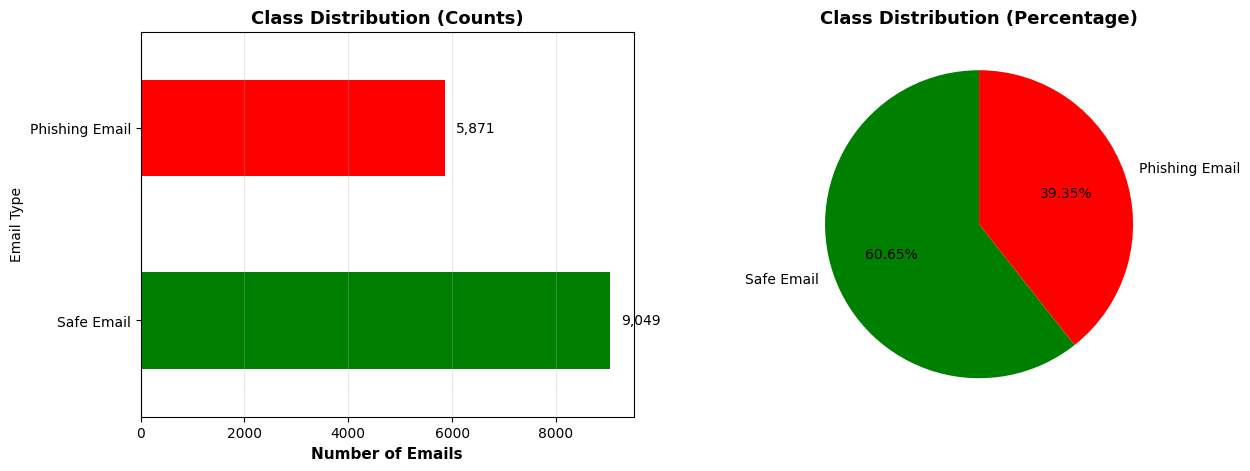

In [15]:
label_cols = ["Email Type"]
counts = train_df[label_cols[0]].value_counts().sort_values(ascending=False)
percentages = (counts / len(train_df)) *100

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

colors = ["green", "red"]
counts.plot(kind='barh', ax=ax1, color=colors)
ax1.set_xlabel('Number of Emails', fontsize=11, fontweight='bold')
ax1.set_title('Class Distribution (Counts)', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, (label, value) in enumerate(counts.items()):
    ax1.text(value + 200, i, f'{value:,}', va='center', fontsize=10)

percentages.plot(kind='pie', ax=ax2, colors=colors, autopct='%1.2f%%', startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')
ax2.set_ylabel('')
plt.show()

## Loading models (pre-trained)

In [19]:
REPO_ID = "colinthebomb/e-ml-models"

print("Downloading pre-trained models from HuggingFace...")
for f in ['bow_vectorizer.joblib', 'bow_lr.joblib',
          'tfidf_vectorizer.joblib', 'tfidf_lr.joblib',
          'xgb_model.joblib', 'w2v.model']:
    hf_hub_download(repo_id=REPO_ID, filename=f, local_dir='.')
    print(f"  Downloaded {f}")

bow_vectorizer       = joblib.load('bow_vectorizer.joblib')
bow_lr_classifier    = joblib.load('bow_lr.joblib')
tf_idf_vectorizer    = joblib.load('tfidf_vectorizer.joblib')
tf_idf_lr_classifier = joblib.load('tfidf_lr.joblib')
xgb_model            = joblib.load('xgb_model.joblib')
w2v_model            = Word2Vec.load('w2v.model')

print("\nAll models loaded!")

bow_vectorizer.joblib:   0%|          | 0.00/31.0M [00:00<?, ?B/s]

  Downloaded bow_vectorizer.joblib


bow_lr.joblib:   0%|          | 0.00/11.6M [00:00<?, ?B/s]

  Downloaded bow_lr.joblib


tfidf_vectorizer.joblib:   0%|          | 0.00/18.4M [00:00<?, ?B/s]

...

  Downloaded tfidf_lr.joblib


xgb_model.joblib:   0%|          | 0.00/4.06M [00:00<?, ?B/s]

  Downloaded xgb_model.joblib


w2v.model:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

  Downloaded w2v.model

All models loaded!


In [20]:
# Prepare shared text and labels
train_email_text = train_df["Email Text"].fillna("")
test_email_text  = test_df["Email Text"].fillna("")

Y_train = (train_df["Email Type"] == "Phishing Email").astype(int)
Y_test  = (test_df["Email Type"] == "Phishing Email").astype(int)

# Word2Vec preprocessing functions
def is_junk(word, threshold=0.3):
    if len(word) <3:
        return False
    vowels = sum(1 for char in word if char in 'aeiou')
    vowel_ratio = vowels / len(word)
    return vowel_ratio < .15 or vowel_ratio > .8

def preprocess_email(text):
    if pd.isna(text):
        return []
    text= text.lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\\x[0-9a-fA-F]{2}', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = simple_preprocess(text, deacc=True)
    tokens = [word for word in tokens if not is_junk(word)]
    return tokens

def get_document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) >0:
        mean_vec = np.mean(vectors, axis=0)
        max_vec = np.max(vectors, axis=0)
        min_vec = np.min(vectors, axis=0)
        return np.concatenate([mean_vec, max_vec, min_vec])
    else:
        return np.zeros(vector_size*3)

print("Helper functions and labels ready.")

Helper functions and labels ready.


## Linear Classification Baselines ##

### Logistic Regression with Bag-of-Words Features ###

In [21]:
X_test_bow = bow_vectorizer.transform(test_email_text)
bow_pred   = bow_lr_classifier.predict(X_test_bow)
bow_proba  = bow_lr_classifier.predict_proba(X_test_bow)[:, 1]

print("Evaluating model performance on test data...")

print("\nDetailed Classification Report: Bag-of-Words Features")
print(classification_report(Y_test, bow_pred, target_names=["Safe Email", "Phishing Email"], digits=4))

print("Test AUROC:", roc_auc_score(Y_test, bow_proba))

Evaluating model performance on test data...

Detailed Classification Report: Bag-of-Words Features
                precision    recall  f1-score   support

    Safe Email     0.9884    0.9701    0.9792      1139
Phishing Email     0.9545    0.9821    0.9681       726

      accuracy                         0.9748      1865
     macro avg     0.9714    0.9761    0.9736      1865
  weighted avg     0.9752    0.9748    0.9749      1865

Test AUROC: 0.9964627518702065


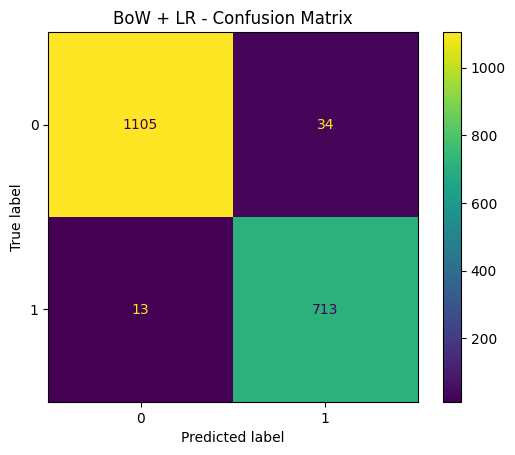

In [22]:
c_matrix = confusion_matrix(Y_test, bow_pred)
ConfusionMatrixDisplay(confusion_matrix=c_matrix).plot()
plt.title('BoW + LR - Confusion Matrix')
plt.show()

## TF-IDF + Logistic Regression

In [23]:
X_test_tfidf = tf_idf_vectorizer.transform(test_email_text)
tfidf_pred   = tf_idf_lr_classifier.predict(X_test_tfidf)
tfidf_proba  = tf_idf_lr_classifier.predict_proba(X_test_tfidf)[:, 1]

print("Evaluating model performance on TEST data...")

print("\nDetailed Classification Report: TF-IDF Features")
print(classification_report(Y_test, tfidf_pred, target_names=["Safe Email", "Phishing Email"], digits=4))

print("Test AUROC:", roc_auc_score(Y_test, tfidf_proba))

Evaluating model performance on TEST data...

Detailed Classification Report: TF-IDF Features
                precision    recall  f1-score   support

    Safe Email     0.9806    0.9754    0.9780      1139
Phishing Email     0.9617    0.9697    0.9657       726

      accuracy                         0.9732      1865
     macro avg     0.9712    0.9726    0.9718      1865
  weighted avg     0.9733    0.9732    0.9732      1865

Test AUROC: 0.9974749490273476


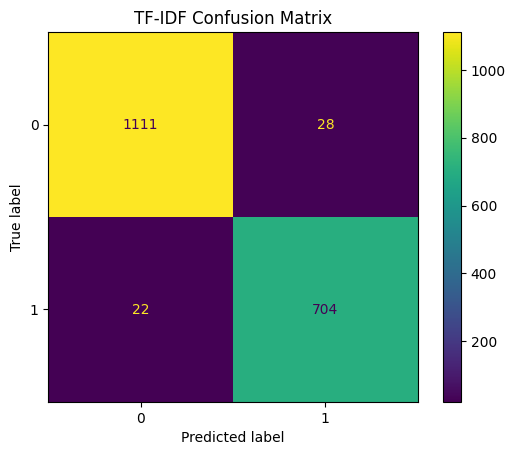

In [24]:
c_matrix = confusion_matrix(Y_test, tfidf_pred)
ConfusionMatrixDisplay(confusion_matrix=c_matrix).plot()
plt.title("TF-IDF Confusion Matrix")
plt.show()

### Word2Vec

In [25]:
print("Preprocessing test emails for Word2Vec...")
test_df['tokens'] = test_df['Email Text'].apply(preprocess_email)
test_df['doc_vector'] = test_df['tokens'].apply(
    lambda x: get_document_vector(x, w2v_model, vector_size=100)
)

X_test_w2v = np.vstack(test_df['doc_vector'].values)
y_test_w2v = (test_df['Email Type'] == 'Phishing Email').astype(int).values

xgb_pred  = xgb_model.predict(X_test_w2v)
xgb_proba = xgb_model.predict_proba(X_test_w2v)[:, 1]

print("Detailed Classification Report: Word2Vec + XGBoost")
print(classification_report(y_test_w2v, xgb_pred,
      target_names=['Safe Email', 'Phishing Email'], digits=4))
print("Test AUROC:", roc_auc_score(y_test_w2v, xgb_proba))

Preprocessing test emails for Word2Vec...
Detailed Classification Report: Word2Vec + XGBoost
                precision    recall  f1-score   support

    Safe Email     0.9787    0.9675    0.9731      1139
Phishing Email     0.9499    0.9669    0.9584       726

      accuracy                         0.9673      1865
     macro avg     0.9643    0.9672    0.9657      1865
  weighted avg     0.9675    0.9673    0.9673      1865

Test AUROC: 0.9955533465390597


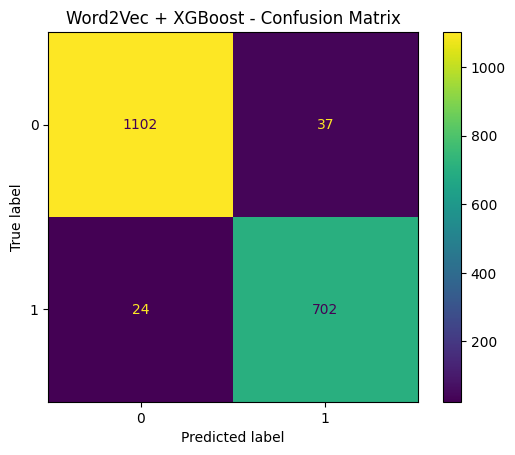

In [26]:
c_matrix = confusion_matrix(y_test_w2v, xgb_pred)
ConfusionMatrixDisplay(confusion_matrix=c_matrix).plot()
plt.title('Word2Vec + XGBoost - Confusion Matrix')
plt.show()

## Fine-Tuned BERT (Pre-computed Results)

Bert evaluation metrics:
Precision: 0.9612
Recall: 0.9609
F1-Score: 0.9609
Accuracy: 0.9609


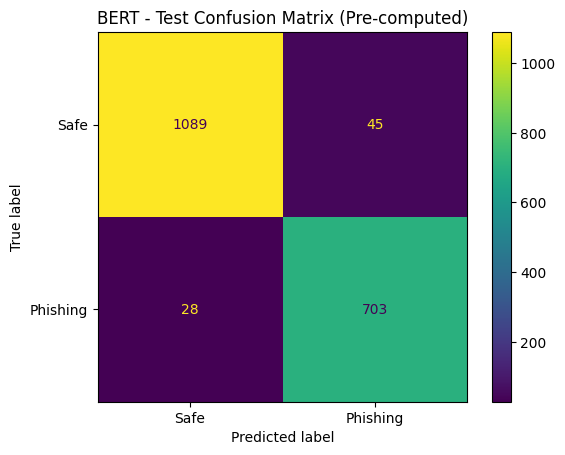

In [27]:
# Pre-computed results (takes too long to run for demo)
bert_results = {
    "Precision": 0.9612, "Recall": 0.9609, "F1-Score": 0.9609, "Accuracy": 0.9609
}
bert_cm = np.array([[1089, 45], [28, 703]])

print("Bert evaluation metrics:")
print(f"Precision: {bert_results['Precision']:.4f}")
print(f"Recall: {bert_results['Recall']:.4f}")
print(f"F1-Score: {bert_results['F1-Score']:.4f}")
print(f"Accuracy: {bert_results['Accuracy']:.4f}")

ConfusionMatrixDisplay(bert_cm, display_labels=['Safe', 'Phishing']).plot()
plt.title('BERT - Test Confusion Matrix (Pre-computed)')
plt.show()

## LoRA Fine-Tuned Gemma-3 1B (Pre-computed Results)

LoRA LLM evaluation metrics:
Precision: 0.9480
Recall: 0.9480
F1-Score: 0.9479
Accuracy: 0.9480


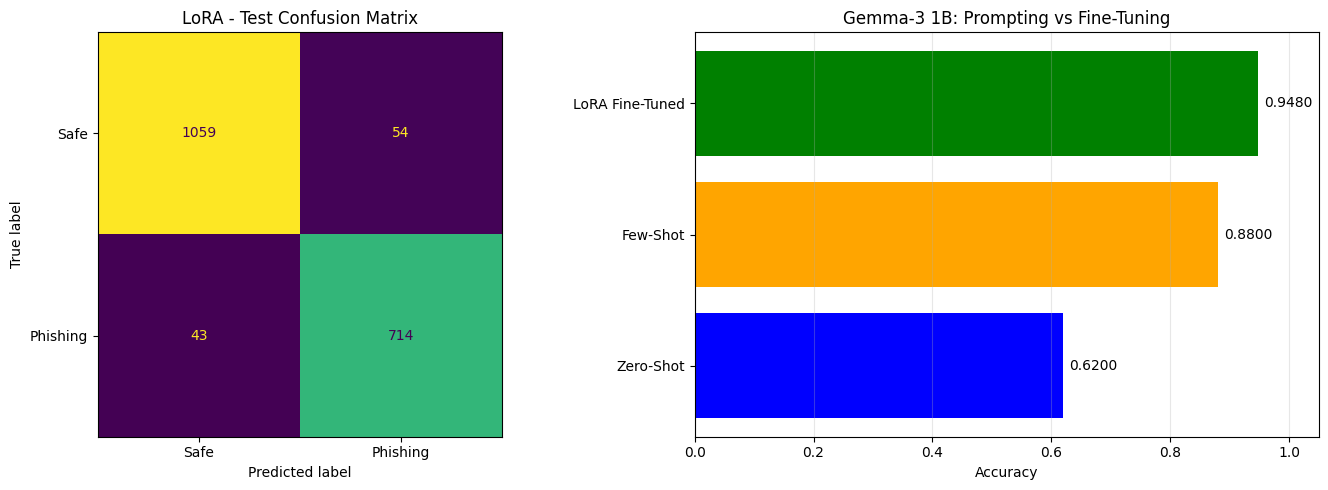

In [28]:
# Pre-computed results (takes too long to run for demo)
lora_results = {
    "Precision": 0.9480, "Recall": 0.9480, "F1-Score": 0.9479, "Accuracy": 0.9480
}
lora_cm = np.array([[1059, 54],[43, 714]])

zero_shot_acc = 0.62
few_shot_acc  = 0.88
lora_acc = lora_results["Accuracy"]

print("LoRA LLM evaluation metrics:")
print(f"Precision: {lora_results['Precision']:.4f}")
print(f"Recall: {lora_results['Recall']:.4f}")
print(f"F1-Score: {lora_results['F1-Score']:.4f}")
print(f"Accuracy: {lora_results['Accuracy']:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(lora_cm, display_labels=['Safe', 'Phishing']).plot(ax=ax1, colorbar=False)
ax1.set_title('LoRA - Test Confusion Matrix')

methods = ["Zero-Shot", "Few-Shot", "LoRA Fine-Tuned"]
accs    = [zero_shot_acc, few_shot_acc, lora_acc]
colors  = ["blue", "orange", "green"]
bars = ax2.barh(methods, accs, color=colors)
ax2.set_xlabel('Accuracy')
ax2.set_title('Gemma-3 1B: Prompting vs Fine-Tuning')
ax2.set_xlim(0, 1.05)
ax2.grid(axis='x', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax2.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
             f"{acc:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Model Comparison — In-Distribution Test Set

                 Precision  Recall  F1-Score   AUROC  Accuracy
Model                                                         
BoW + LR            0.9752  0.9748    0.9749  0.9965    0.9748
TF-IDF + LR         0.9733  0.9732    0.9732  0.9975    0.9732
W2V + XGBoost       0.9675  0.9673    0.9673  0.9956    0.9673
Fine-Tuned BERT     0.9612  0.9609    0.9609  0.9978    0.9609
LoRA Gemma-3 1B     0.9480  0.9480    0.9479  0.9890    0.9480


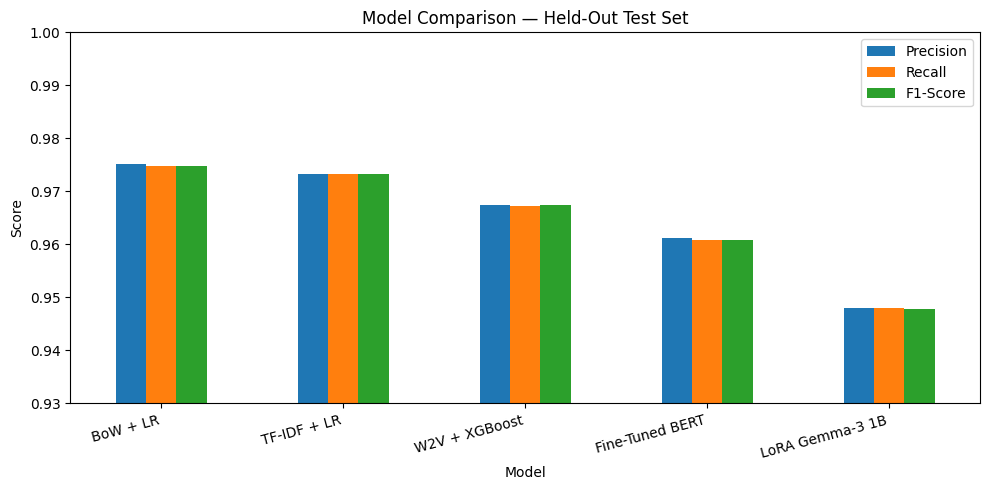

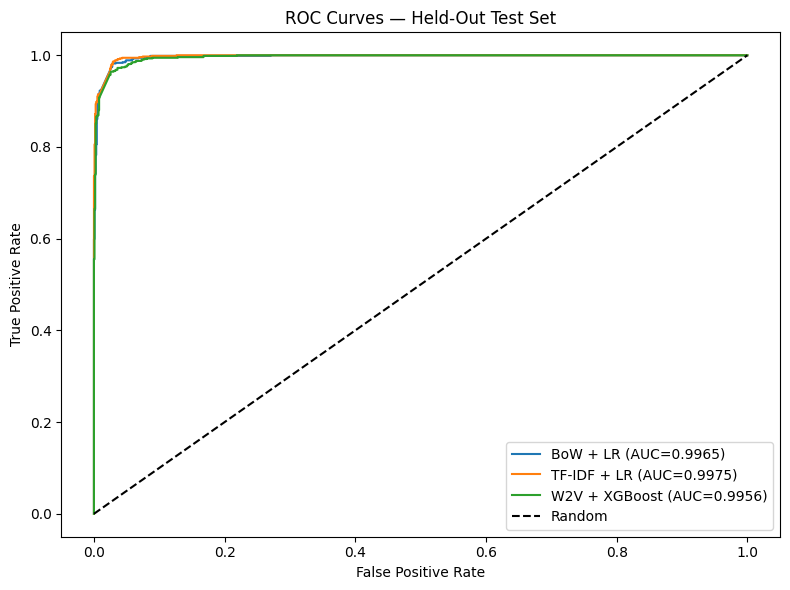

In [29]:
live_models = {
    "BoW + LR":        (bow_pred,   bow_proba,   Y_test),
    "TF-IDF + LR":     (tfidf_pred, tfidf_proba, Y_test),
    "W2V + XGBoost":   (xgb_pred,   xgb_proba,   y_test_w2v),
}

rows = []
for name, (pred, proba, yt) in live_models.items():
  rows.append({
      "Model": name,
      "Precision": precision_score(yt, pred, average='weighted'),
      "Recall":    recall_score(yt, pred, average='weighted'),
      "F1-Score":  f1_score(yt, pred, average='weighted'),
      "AUROC":     roc_auc_score(yt, proba),
      "Accuracy":  accuracy_score(yt, pred),
  })

rows.append({"Model": "Fine-Tuned BERT", **bert_results, "AUROC": 0.9978})
rows.append({"Model": "LoRA Gemma-3 1B", **lora_results, "AUROC": 0.9890})

comparison_df = pd.DataFrame(rows).set_index("Model")
print(comparison_df.round(4).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df[["Precision", "Recall", "F1-Score"]].plot(kind='bar', ax=ax)
ax.set_ylim(0.93, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Held-Out Test Set')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
for name, (pred, proba, yt) in live_models.items():
    fpr, tpr, _ = roc_curve(yt, proba)
    auc_val = roc_auc_score(yt, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Held-Out Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Out-of-Distribution Evaluation
We evaluate on 4 external datasets spanning 1995–2022. BoW, TF-IDF, and Word2Vec models run live inference. BERT and LoRA results are merged from pre-computed evaluations. Any year with fewer than 50 samples is excluded."

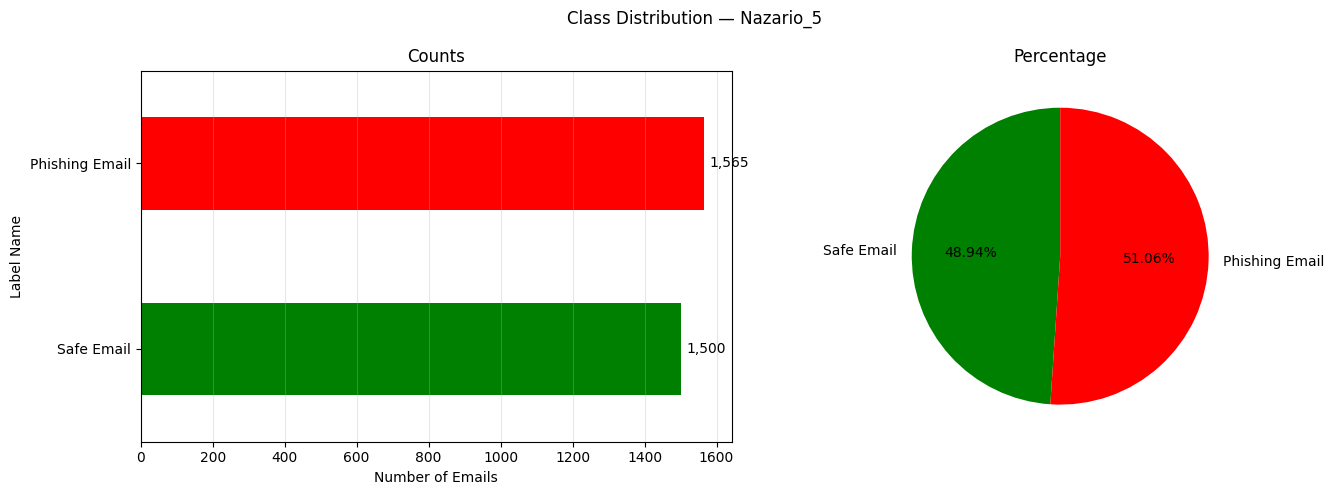

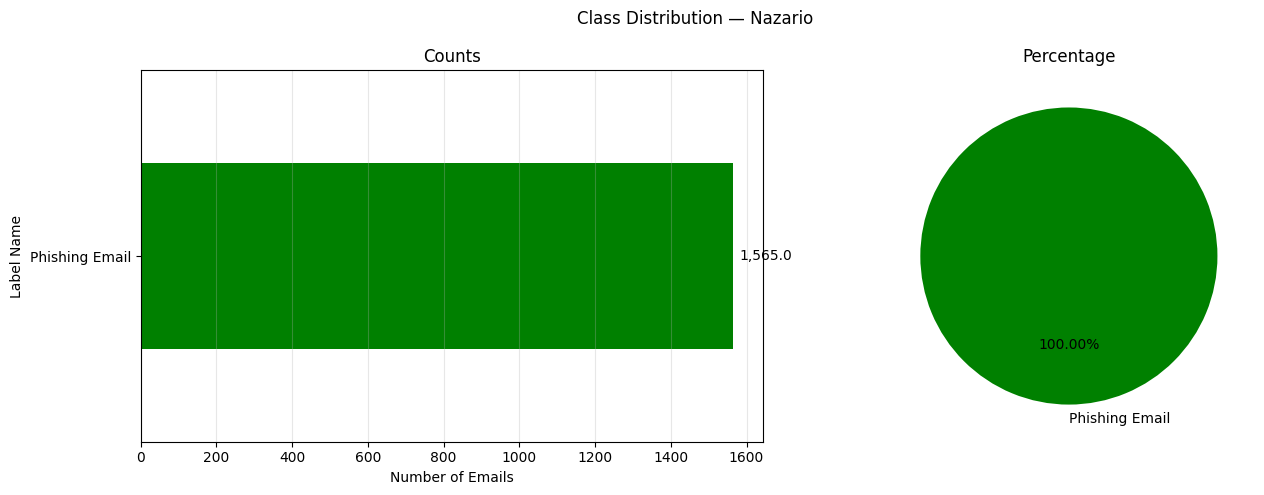

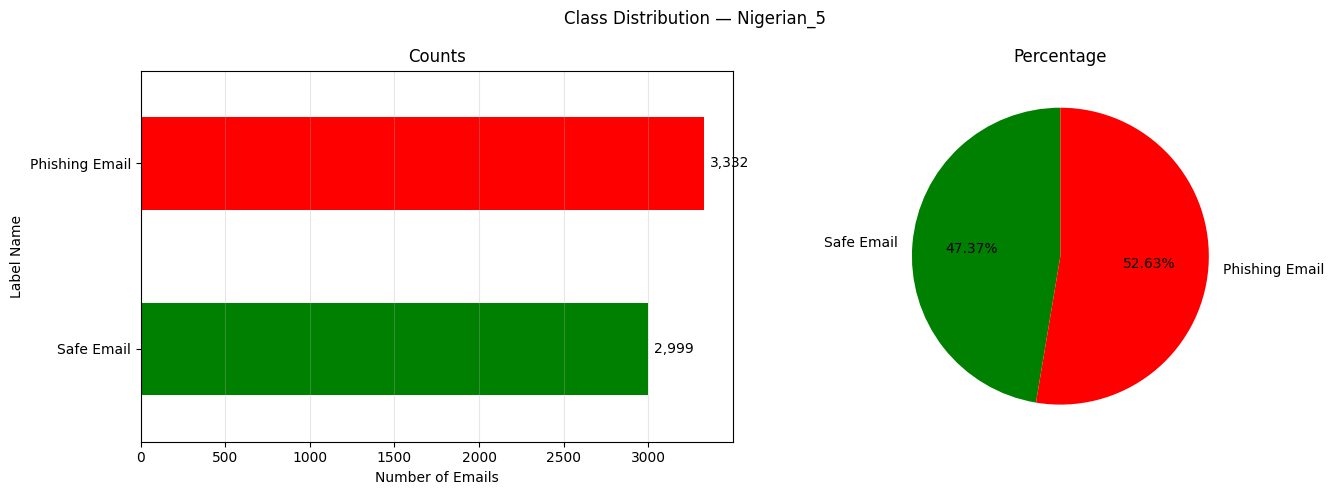

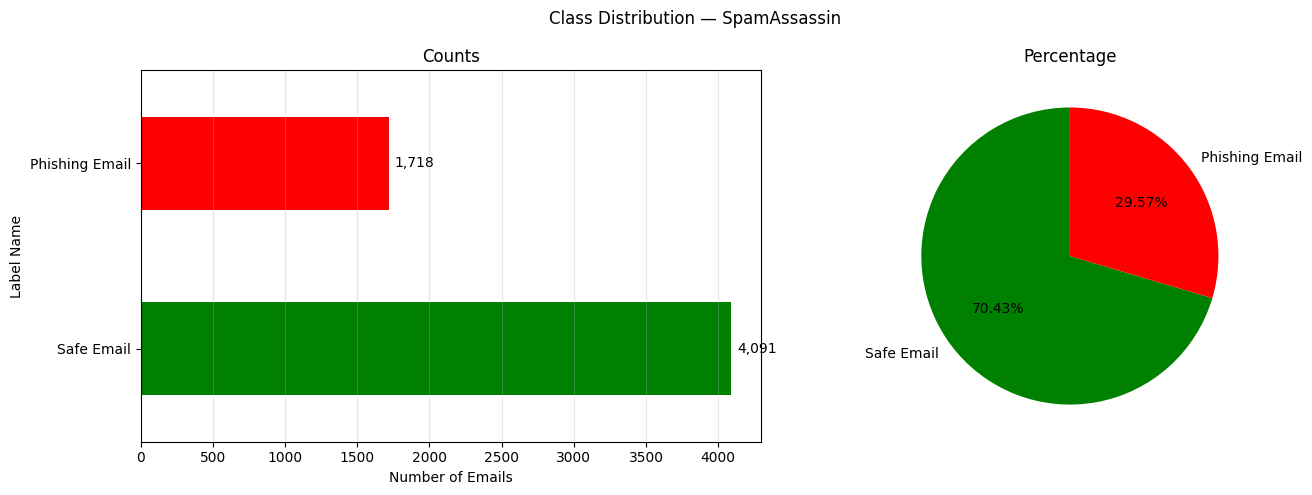

In [31]:
datasets_to_plot = {
    "Nazario_5": "Nazario_5.csv",
    "Nazario": "Nazario.csv",
    "Nigerian_5": "Nigerian_5.csv",
    "SpamAssassin": "SpamAssasin.csv",
}

label_map = {0: "Safe Email", 1: "Phishing Email"}
colors = ["green", "red"]

for title, path in datasets_to_plot.items():
    df = pd.read_csv(path)
    df["Label Name"] = df["label"].map(label_map)

    counts = df["Label Name"].value_counts().reindex(["Safe Email", "Phishing Email"]).dropna()
    percentages = (counts / len(df)) * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Class Distribution — {title}')

    counts.plot(kind='barh', ax=ax1, color=colors)
    ax1.set_xlabel('Number of Emails')
    ax1.set_title('Counts')
    ax1.grid(axis='x', alpha=0.3)
    for i, (label, value) in enumerate(counts.items()):
        ax1.text(value + max(counts) * 0.01, i, f'{value:,}', va='center')

    percentages.plot(kind='pie', ax=ax2, colors=colors, autopct='%1.2f%%', startangle=90)
    ax2.set_title('Percentage')
    ax2.set_ylabel('')

    plt.tight_layout()
    plt.show()

## Evaluating OOD


  Nazario_5

BoW + LR:
                precision    recall  f1-score   support

    Safe Email     0.7599    0.9053    0.8263      1500
Phishing Email     0.8889    0.7259    0.7992      1565

      accuracy                         0.8137      3065
     macro avg     0.8244    0.8156    0.8127      3065
  weighted avg     0.8258    0.8137    0.8124      3065


TF-IDF + LR:
                precision    recall  f1-score   support

    Safe Email     0.7566    0.9427    0.8394      1500
Phishing Email     0.9281    0.7093    0.8041      1565

      accuracy                         0.8235      3065
     macro avg     0.8423    0.8260    0.8217      3065
  weighted avg     0.8441    0.8235    0.8214      3065


W2V + XGBoost:
                precision    recall  f1-score   support

    Safe Email     0.7965    0.9473    0.8654      1500
Phishing Email     0.9383    0.7681    0.8447      1565

      accuracy                         0.8558      3065
     macro avg     0.8674    0.8577    0.8

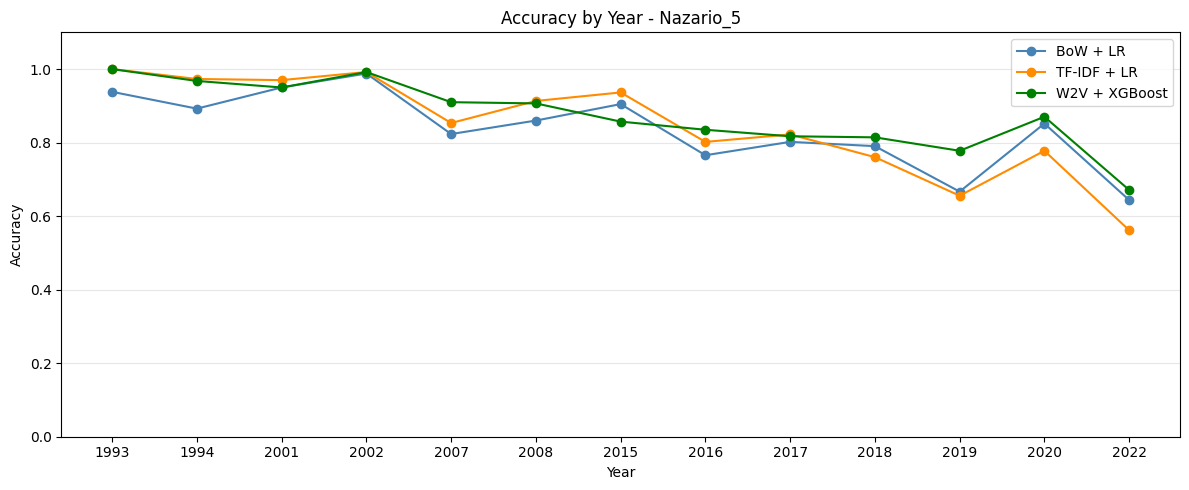

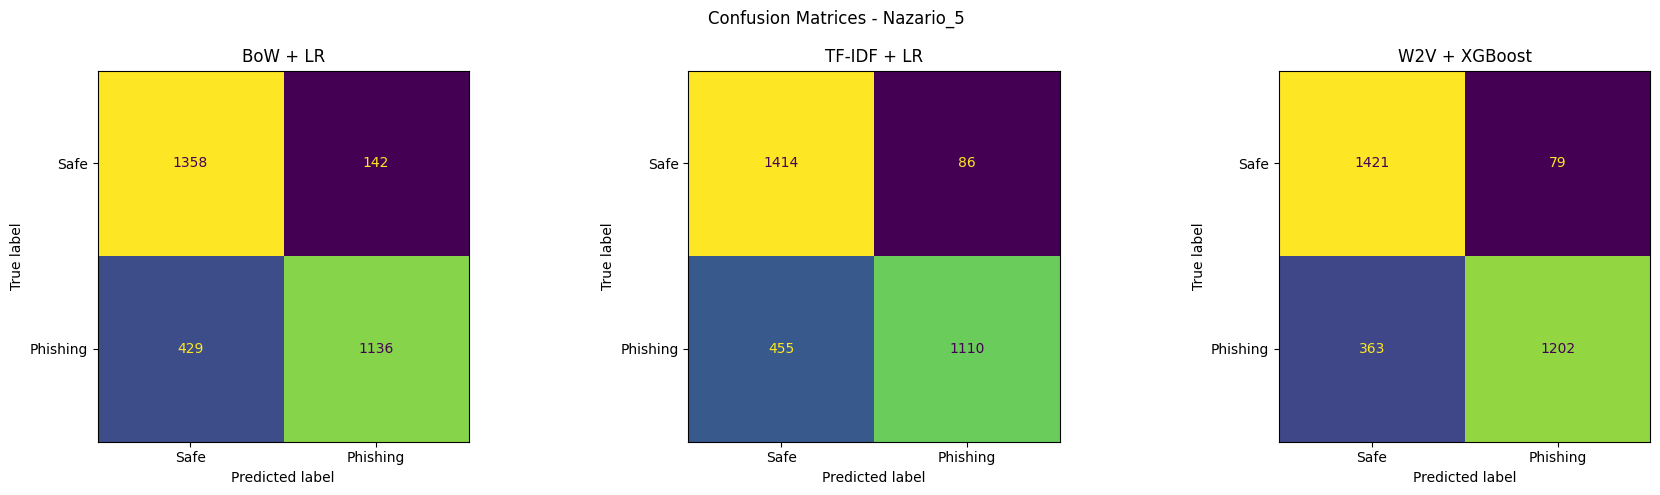

In [33]:
precomputed_ood = {
    "Nazario_5": {
        "Fine-Tuned BERT": {"Precision": 0.8768, "Recall": 0.8653, "F1-Score": 0.8645},
        "LoRA Gemma": {"Precision": 0.8655, "Recall": 0.8626, "F1-Score": 0.8621},
    },
}

def evaluate_ood(path, title, min_n=50):
    df = pd.read_csv(path)
    has_date = 'date' in df.columns
    if has_date:
        df['year'] = pd.to_datetime(df['date'], errors='coerce', utc=True).dt.year.fillna(-1).astype(int)

    text = df['body'].fillna('')
    df['label'] = df['label'].astype(int)
    df['tokens'] = text.apply(preprocess_email)
    df['doc_vector'] = df['tokens'].apply(lambda t: get_document_vector(t, w2v_model))

    df['pred_bow'] = bow_lr_classifier.predict(bow_vectorizer.transform(text))
    df['pred_tfidf'] = tf_idf_lr_classifier.predict(tf_idf_vectorizer.transform(text))
    df['pred_xgb'] = xgb_model.predict(np.vstack(df['doc_vector'].values))

    models = [
        ('BoW + LR', 'pred_bow', 'steelblue'),
        ('TF-IDF + LR', 'pred_tfidf', 'darkorange'),
        ('W2V + XGBoost', 'pred_xgb', 'green'),
    ]

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")

    for name, col, _ in models:
        print(f"\n{name}:")
        print(classification_report(df['label'], df[col],
              target_names=['Safe Email', 'Phishing Email'], digits=4))

    if title in precomputed_ood:
        for model_name, met in precomputed_ood[title].items():
            print(f"{model_name} (pre-computed):")
            print(f"  Precision: {met['Precision']:.4f}  |  Recall: {met['Recall']:.4f}  |  F1: {met['F1-Score']:.4f}")

    if has_date:
        fig, ax = plt.subplots(figsize=(12, 5))
        for name, col, color in models:
            yr_data = []
            for y in sorted(df['year'].unique()):
                if y == -1: continue
                m = df['year'] == y
                if m.sum() < min_n: continue
                yr_data.append({'year': y, 'acc': accuracy_score(df.loc[m, 'label'], df.loc[m, col])})
            if yr_data:
                yr_df = pd.DataFrame(yr_data)
                ax.plot(yr_df['year'].astype(str), yr_df['acc'], marker='o', color=color, label=name)
        ax.set_ylim(0, 1.1)
        ax.set_xlabel('Year')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'Accuracy by Year - {title}')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrices - {title}')
    for ax, (name, col, _) in zip(axes, models):
        ConfusionMatrixDisplay(
            confusion_matrix(df['label'], df[col]),
            display_labels=['Safe', 'Phishing']
        ).plot(ax=ax, colorbar=False)
        ax.set_title(name)
    plt.tight_layout()
    plt.show()

evaluate_ood("Nazario_5.csv", "Nazario_5")